### ENSIMAG – Grenoble INP – UGA - Academic year 2025-2026
# Introduction to Statistical Learning and Applications ([website](https://github.com/ISLA-Grenoble/2025-main))

- Pedro L. C. Rodrigues -- `pedro.rodrigues@inria.fr`

- Isabella Costa Maia -- `isabella.costa-maia@grenoble-inp.fr`

- Pierre Marrec -- `pierre.marrec@inria.fr`

***

### ⚠️ General guidelines for TPs

The report should contain graphical representations and explanatory text. For each graph, axis names should be provided as well
as a legend when it is appropriate. Figures should be explained by a few sentences in the text. Answer to
the questions in order and refer to the question number in your report. Computations and
graphics have to be performed in `python`. The report should be written as a jupyter notebook. This is a file format that allows users to format documents containing text written in markdown and `python` instructions. You should include all of the `python` instructions that you have used in the document so that it may be possible to replicate your results.

***

# 🖥️ TP2: Principal components regression in genetics

The goal of this TP session is to use genetic markers to predict the geographical origin of a set of indians from South, Central, and North America. We propose to build two regression linear models to predict the latitude and longitude of an individual based on its genetic markers. Because the number of markers (p = 5709) is larger than the number of samples (N = 494), the predictors of the regression model will be the outputs of a principal component analysis (PCA) performed on the genetic markers. A genetic marker is encoded 1 if the individual has a mutation, 0 elsewhere.

## ▶️ Exercise 1: Data visualization (1 point)

NB: To do this exercise you will have to install packages `geopandas` and `geodatasets`.

Download dataset `NAm2.txt` from [here](https://github.com/ISLA-Grenoble/2025-main/blob/main/TP/TP2/NAm2.txt). Each row of the dataset corresponds to an individual and the columns have explicit names. The third column contains the names of the tribes to which each individual pertains. Columns 7 and 8 contain the latitude and the longitude and from Column 9 onwards are genetic markers, which are encoded are 0 or 1. Run the code described below and explain how it works.

```
import pandas as pd
import geopandas as gpd
import geodatasets
import matplotlib.pyplot as plt

# Load the data
file_path = 'NAm2.txt'
df = pd.read_csv(file_path, delimiter=' ')

# Extract relevant columns
latitude = df.iloc[:, 6]
longitude = df.iloc[:, 7]
tribes = df.iloc[:, 2]

# Create a GeoDataFrame
gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(longitude, latitude))

# Plotting
world = gpd.read_file(geodatasets.get_path('naturalearth.land'))
fig, ax = plt.subplots(figsize=(8.0, 6.5))
plt.subplots_adjust(left=0.0, right=0.90, bottom=0.10, top=0.92)
world.clip([-140, -55, -25, 75]).plot(ax=ax, color='white', edgecolor='black')
marker_list = ['o', 'v', 's']
colors_list = [f'C{i}' for i in range(9)]
for i, tribe in enumerate(gdf['Pop'].unique()):
    members_tribe = gdf[gdf['Pop'] == tribe]
    ax.scatter(members_tribe['long'], members_tribe['lat'], 
               marker=marker_list[i//9], 
               color=colors_list[i%9], label=tribe)
ax.legend(loc='center right', bbox_to_anchor=(1.4, 0.5))
ax.set_title('Tribes Locations')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
fig.show()
```

In [12]:
import pandas as pd
import geopandas as gpd
import geodatasets
import matplotlib.pyplot as plt
import numpy as np 
from sklearn.linear_model import LinearRegression
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from math import radians
from sklearn.metrics.pairwise import haversine_distances

from sklearn.pipeline import make_pipeline
from sklearn.model_selection import GroupKFold, cross_val_predict




/var/folders/2q/95dfchgn6ms1p6p1nzlqf0th0000gn/T/ipykernel_57225/2410588162.py:67: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


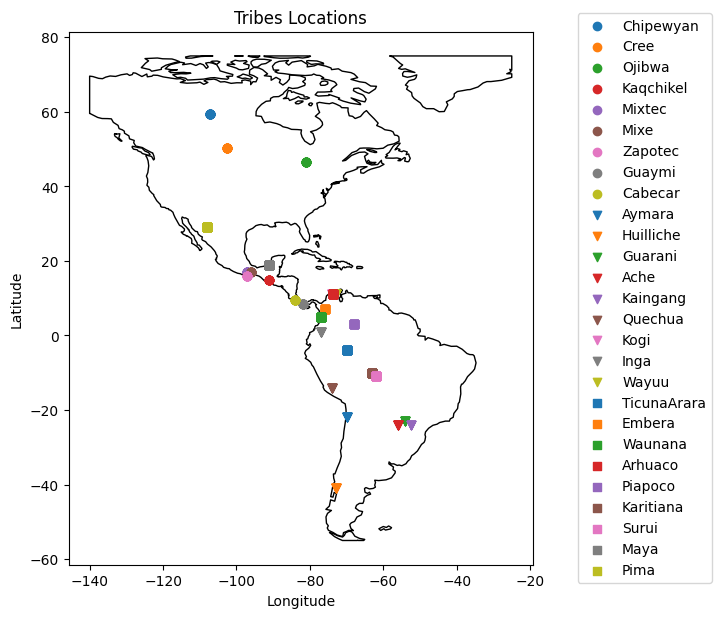

In [13]:
# Load the data
file_path = 'NAm2.txt'  # path to the file containing the data
df = pd.read_csv(file_path, delimiter=' ')  # reads the text file and loads it into a pandas DataFrame (separator = space)

# Extract relevant columns
latitude = df.iloc[:, 6]  # selects all rows from the 6th column (latitude)
longitude = df.iloc[:, 7]  # selects all rows from the 7th column (longitude)
tribes = df.iloc[:, 2]  # selects the column containing tribes/populations

# Create a GeoDataFrame
gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(longitude, latitude))
# creates a GeoDataFrame from the DataFrame
# adds a "geometry" column containing Point objects (longitude, latitude)

# Plotting
world = gpd.read_file(geodatasets.get_path('naturalearth.land'))
# loads a world map (Natural Earth geographic data)
# world is a GeoDataFrame containing the continents

fig, ax = plt.subplots(figsize=(8.0, 6.5))  
# creates a matplotlib figure and an axis to draw the map

plt.subplots_adjust(left=0.0, right=0.90, bottom=0.10, top=0.92)
# adjusts the margins around the figure to leave space for the legend

world.clip([-140, -55, -25, 75]).plot(ax=ax, color='white', edgecolor='black')
# clip restricts the display of the map to a given geographic area
# here we only display part of the world (Americas region)
# the map is drawn on the axis ax

marker_list = ['o', 'v', 's']  # list of marker shapes (circle, triangle, square)

colors_list = [f'C{i}' for i in range(9)]
# creates a list of 9 default matplotlib colors: C0, C1, ..., C8

for i, tribe in enumerate(gdf['Pop'].unique()):  
    # .unique() retrieves all distinct tribes without duplicates
    # enumerate provides both the index i and the value tribe

    members_tribe = gdf[gdf['Pop'] == tribe]
    # filters the GeoDataFrame to keep only individuals belonging to the current tribe
    # gdf['Pop'] == tribe creates a True/False series
    # gdf[...] keeps only rows where the condition is True

    ax.scatter(members_tribe['long'], members_tribe['lat'], 
               marker=marker_list[i//9], 
               color=colors_list[i%9], label=tribe)
    # plots the tribe members on the map
    # x = longitude, y = latitude
    # marker=marker_list[i//9]: changes marker shape every 9 groups
    # color=colors_list[i%9]: changes color for each tribe and repeats after 9 colors
    # label=tribe: tribe name for the legend

ax.legend(loc='center right', bbox_to_anchor=(1.4, 0.5))
# adds a legend indicating which color corresponds to which tribe
# bbox_to_anchor allows placing the legend outside the map

ax.set_title('Tribes Locations')
# title of the plot

ax.set_xlabel('Longitude')
# label of the x-axis

ax.set_ylabel('Latitude')
# label of the y-axis

fig.show()
# displays the final figure

## ▶️ Exercise 2: Multiple linear regression (2 points)

Using **only** the genetic markers as predictors, you will estimate a multiple linear regression model to predict the longitude of each individual.

You will proceed in several steps.

**(a)** First, try to estimate the coefficients of the multiple linear regression using the expression seen in class 

$$\hat{\beta} = (X^\top X)^{-1}X^\top y$$

You should proceed as we did in TP1 using `numpy.linalg.solve` to obtain the values of $\beta$. 

Did you run into any errors? What is going on? Relate your answer to the fact that $\text{rank}(X) < p$, where $X \in R^{N*p}$ is the data matrix.

<font color='green'> We obtain the error “LinAlgError: Singular matrix” because the matrix X is not invertible.
We can verify this by computing its rank using:
print("rank X = ", np.linalg.matrix_rank(X))
The rank of X is smaller than p, which means that some columns are linearly dependent. </font>

In [14]:

# Genetic markers
X = df.iloc[:, 8:].copy()

# Add intercept
X.insert(loc=0, column='Intercept', value=np.ones(X.shape[0]))

# Convert to numpy arrays
X = np.asarray(X)
y = np.asarray(df['long'])

# Check rank
print("rank(X) =", np.linalg.matrix_rank(X))
print("number of columns p =", X.shape[1])

# Attempt to compute beta
beta = np.linalg.solve(X.T @ X, X.T @ y)
print(beta)

rank(X) = 494
number of columns p = 5710


LinAlgError: Singular matrix

**(b)** Use function `numpy.linalg.lstsq` to estimate the coefficients (it may take a few seconds to get a result). 

And now? Did you get any errors? Why is that? 

Relate your answer to the difference between functions `numpy.linalg.solve` and `numpy.linalg.lstsq`.

You can check the documention for both functions as well as [this](https://netlib.org/lapack/lug/node27.html) link for more information.

In [15]:
beta,_ ,_,_= np.linalg.lstsq(X,y)
# plus d'erreurs 
print(beta)

[-0.47674258 -0.04005413 -0.01943802 ... -0.2157905  -0.10203467
  0.01814151]


<font color='green'>Using `numpy.linalg.lstsq`, no error is obtained.

This is because `numpy.linalg.lstsq` does not solve the system exactly, but computes a least-squares solution by minimizing:

$$
\|X\hat{\beta} - y\|^2.
$$

In contrast, `numpy.linalg.solve` attempts to solve:

$$
(X^\top X)\beta = X^\top y,
$$

which requires $X^\top X$ to be invertible. However, here $\mathrm{rank}(X) < p$, so $X^\top X$ is singular.

Therefore, `numpy.linalg.lstsq` works even when the columns of $X$ are linearly dependent, which explains why no error is raised. </font>

 **(c)** We will now use `sklearn` to do our linear regression with the help of class `sklearn.linear_model.LinearRegression` whose documentation is available [here](https://scikit-learn.org/1.5/modules/generated/sklearn.linear_model.LinearRegression.html). Note that every estimator from `sklearn` has a `fit` and a `predict` method, which are used to calculate coefficients and predict values (see [here](https://scikit-learn.org/stable/getting_started.html#fitting-and-predicting-estimator-basics) for more info). In our current case, we can do:

```
# select only the genetic markers as predictors
predictors = df.columns[8:]
# create the design matrix
X = df[predictors].values
# get the observed values to predict
y = df['long']
# fit a multiple linear regression model
lr = LinearRegression()
lr.fit(X, y)
```

You should not run into errors now, since `sklearn` also uses `lstsq` to solve the normal equations, as shown [here](https://github.com/scikit-learn/scikit-learn/blob/d666202a9349893c1bd106cc9ee0ff0a807c7cf3/sklearn/linear_model/_base.py#L682) (though it uses the `scipy` implementation instead of the `numpy` for "historical" reasons). Check the values of the estimated coefficients stored as an attribute in `lr.coef_`, are they the same as the ones obtained in item **(b)**? Probably not. This is because `sklearn` re-centers the predictors before estimating the coefficients of the linear regression, as shown [here](https://github.com/scikit-learn/scikit-learn/blob/d666202a9349893c1bd106cc9ee0ff0a807c7cf3/sklearn/linear_model/_base.py#L622). What would be a practical reason for doing such re-centering systematically? Hint: it has to do with how to interpret the intercept of the model. 

In [125]:
# select only the genetic markers as predictors
predictors = df.columns[8:]
# create the design matrix
X = df[predictors].values
# get the observed values to predict
y = df['long']
# fit a multiple linear regression model
lr = LinearRegression()
lr.fit(X, y)
test = lr.coef_ - beta[1:]
print("Difference entre les coefs de sklearn et de notre minimisation :",test)

Difference entre les coefs de sklearn et de notre minimisation : [ 6.44246928e-04 -5.08917520e-03 -2.14199507e-04 ...  2.63835291e-01
  1.21840526e-02  8.88737353e-04]


<font color='green'> `sklearn` centers the predictors before estimating the regression coefficients.
This makes the intercept easier to interpret. Without centering, the intercept corresponds to the predicted value of $y$ when all predictors are equal to zero, which is often not meaningful.
After centering, the intercept corresponds to the predicted value of $y$ for an observation with average predictor values. </font>

## ▶️ Exercise 3: Principal components analysis (5 points)

**(a)** Explain in a few words the main concepts and ideas underlying the principal component analysis (PCA). You should include both the geometric and statistical interpretations of PCA.

<font color='green'>
Principal Component Analysis (PCA) is a dimensionality reduction technique used to transform a dataset with many possibly correlated variables into a smaller set of uncorrelated variables called principal components.

From a geometric perspective, PCA identifies orthogonal directions in the data space along which the variance is maximized. The data are projected onto these directions, allowing a lower-dimensional representation while preserving as much variability as possible.

From a statistical perspective, PCA relies on the eigen-decomposition of the covariance matrix of the data. The principal components are the eigenvectors of this matrix, and the amount of variance explained by each component is given by the corresponding eigenvalues. </font>

**(b)** Use the estimator defined in `sklearn.decomposition.PCA` to do a PCA on the dataset. Plot the first two dimensions of the projected data points on a scatterplot. The scattered points should have different markers and colors depending on which tribe they belong to. You can use the same color/marker style from **Exercise 2** or propose a new one.

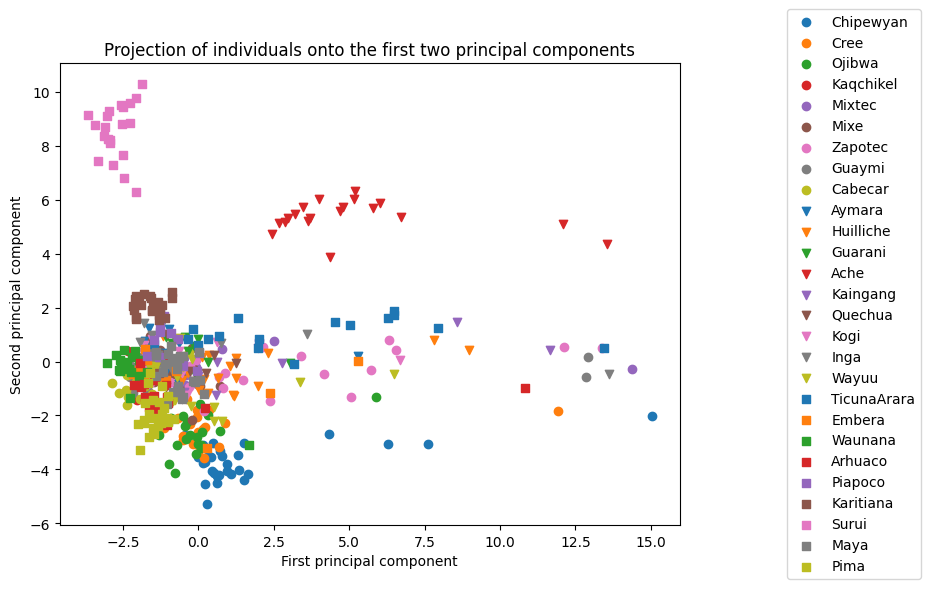

In [16]:

# Select only genetic markers
X = df.iloc[:, 8:].values
tribes = df.iloc[:, 2]

# Perform PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Plot the projected data
marker_list = ['o', 'v', 's']
colors_list = [f'C{i}' for i in range(9)]

plt.figure(figsize=(8, 6))

for i, tribe in enumerate(tribes.unique()):
    members = tribes == tribe
    plt.scatter(
        X_pca[members, 0],
        X_pca[members, 1],
        marker=marker_list[i // 9],
        color=colors_list[i % 9],
        label=tribe
    )

plt.xlabel('First principal component')
plt.ylabel('Second principal component')
plt.title('Projection of individuals onto the first two principal components')
plt.legend(loc='center right', bbox_to_anchor=(1.4, 0.5))
plt.show()


**(c)** Remember from our class that the results of PCA are affected when pre-processing transformations are applied to the data. We will illustrate this using `sklearn.preprocessing.StandardScaler` as per:
```
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X)
X_std = scaler.transform(X)
```
Redo the 2D scatter plot from item **(b)** on the normalized version of the datast. How does it compare to your previous plot?

/var/folders/2q/95dfchgn6ms1p6p1nzlqf0th0000gn/T/ipykernel_57225/4016667241.py:23: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


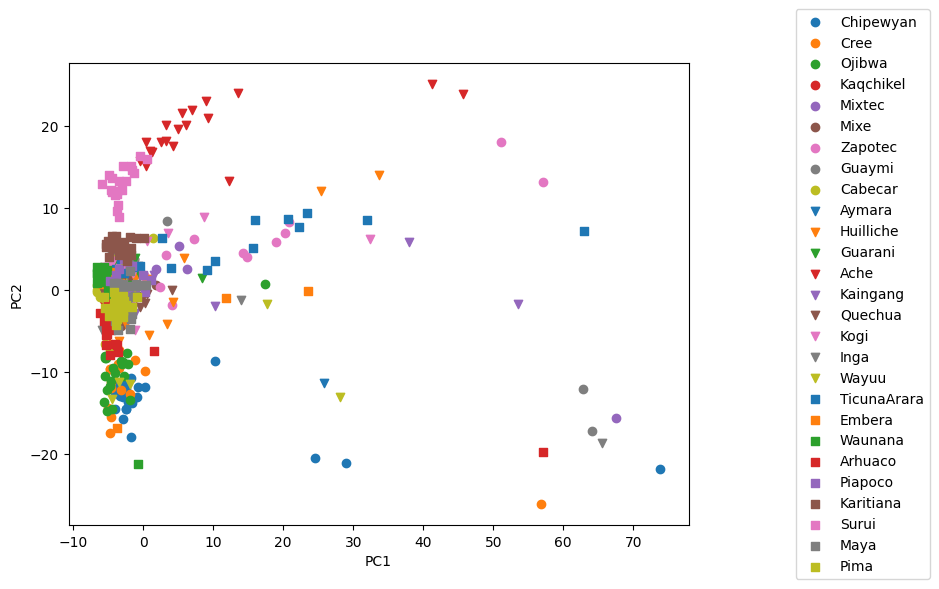

In [17]:
scaler = StandardScaler()
scaler.fit(X)
X_std = scaler.transform(X)
pca = PCA(n_components=2, random_state=42)

X_red = pca.fit_transform(X_std)

fig, ax = plt.subplots(figsize=(8.0, 6))

marker_list = ['o', 'v', 's'] #differents markers 
colors_list = [f'C{i}' for i in range(9)]
for i, tribe in enumerate(gdf['Pop'].unique()):# .unique() evite les doublons 
    members= gdf['Pop'] == tribe
    ax.scatter(
        X_red[members,0],
        X_red[members,1],
        marker = marker_list[i//9],
        color = colors_list[i%9],
        label = tribe)
ax.legend(loc='center right', bbox_to_anchor=(1.4, 0.5))
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
fig.show()



<font color='green'>Compared to the previous plot (without standardization), the global structure is similar: tribes that were close remain roughly in the same regions of the 2D PCA space. However, the separation between some groups is slightly less clear after scaling, with a bit more overlap/noise. This is consistent with the fact that markers are binary (0/1) and already on a comparable scale, so standardization does not bring a clear benefit here.</font>

**(d)** Given the results in **(b)** and **(c)**, what can you conclude regarding the necessity of standardizing the data points for the dataset consider in this TP?

<font color='green'>
In this case, standardizing the data does not improve the PCA results and may even make them worse.

The genetic markers are binary variables (0 or 1), so they are already on the same scale. Standardization transforms these values by centering and scaling them, which can distort the original structure of the data.

In particular, variables with low variance (rare mutations) may be artificially amplified, introducing more noise into the PCA.

As a result, the clusters observed after standardization may be less clear than those obtained without scaling.

Therefore, for this dataset, standardization is not necessary and can even degrade the quality of the PCA representation.
</font>

**(e)** Which percentage of variance is captured by the first two principal components? How many principal components would you keep if you would like to represent the genetic markers using a minimal number of principal components? To help answering this question, you can use a plot showing the cumulative percentage of variance as a function of the number of principal components.

the percentage of variance captured by the two first PC is :  3.57 %


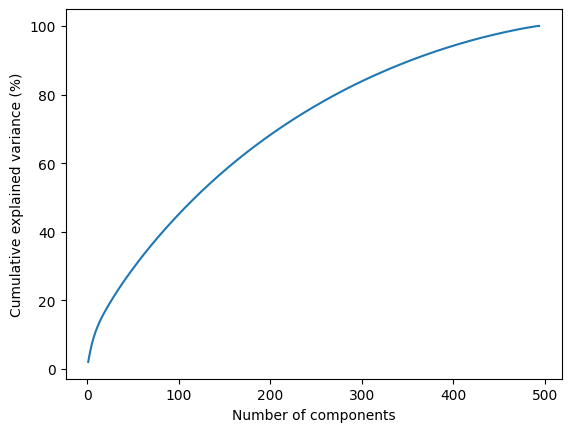

In [18]:
# PCA complète
pca = PCA(n_components=min(X.shape[0], X.shape[1]), random_state=42)
X_red = pca.fit_transform(X)

# variance expliquée par les 2 premières composantes
sum2comp = np.sum(pca.explained_variance_ratio_[:2])
print("the percentage of variance captured by the two first PC is : ", "{:.2f}".format(sum2comp*100), "%")

# variance cumulée
cum_var = np.cumsum(pca.explained_variance_ratio_) * 100

plt.plot(range(1, len(cum_var)+1), cum_var)
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance (%)")
plt.show()

<font color='green'>The first two principal components capture only a small fraction of the total variance (low percentage), so 2 PCs are not sufficient for a faithful representation of the genetic markers. From the cumulative variance plot, a reasonable choice is to keep the smallest number of PCs that reaches a target level of explained variance. For example: about 350-370 PCs for ~90% explained variance, or about 410-430 PCs for ~95%. In practice, I would keep around 250-360 PCs, which is a good compromise between dimensionality reduction and information preservation.</font>

## ▶️ Exercise 4: Principal components regression (4 points)

**(a)** Predict the latitude and the longitude of all points from the dataset using the scores of the first 250 PCA axes. Plot the predicted spatial coordinates using the same style and structure from **Exercise 1** and compare the results from each plot. What can you conclude? Does the new map illustrate somehow too optimistically (or too pessimistically) the ability to find geographical origin of individuals outside the database from its genetic markers? Justify your answer.

/var/folders/2q/95dfchgn6ms1p6p1nzlqf0th0000gn/T/ipykernel_57225/588299515.py:42: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


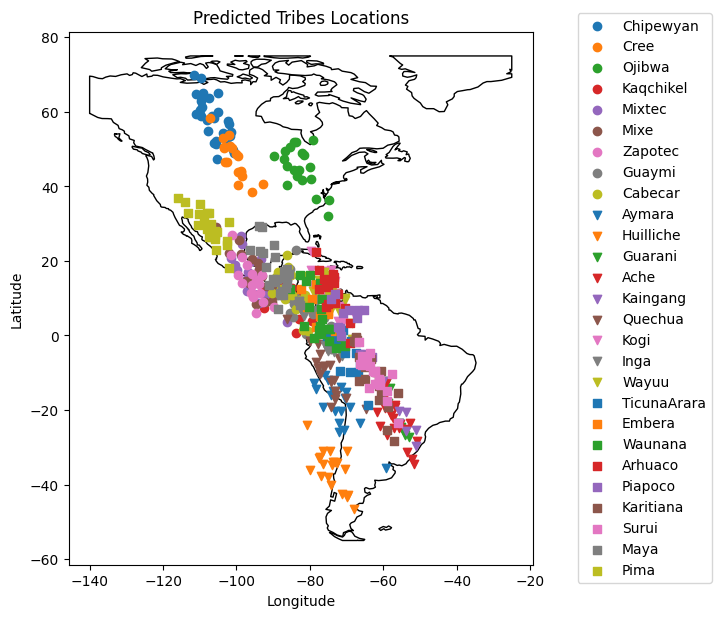

In [19]:
# select only the genetic markers as predictors
predictors = df.columns[8:]
# create the design matrix
X = df[predictors].values
# get the observed values to predict
y_long = df['long']
y_lat = df['lat']

# fit a multiple linear regression model
pca = PCA(n_components=250, random_state=42)
Xpca = pca.fit_transform(X)

lr_long = LinearRegression()
lr_long.fit(Xpca, y_long)

lr_lat = LinearRegression()
lr_lat.fit(Xpca, y_lat)

# prédictions pour tous les individus
pred_long = lr_long.predict(Xpca)
pred_lat = lr_lat.predict(Xpca)

marker_list = ['o', 'v', 's']
colors_list = [f'C{i}' for i in range(9)]

fig, ax = plt.subplots(figsize=(8.0, 6.5))
plt.subplots_adjust(left=0.0, right=0.90, bottom=0.10, top=0.92)

world.clip([-140, -55, -25, 75]).plot(ax=ax, color='white', edgecolor='black')

for i, tribe in enumerate(gdf['Pop'].unique()):
    members_tribe = gdf['Pop'] == tribe
    ax.scatter(pred_long[members_tribe], pred_lat[members_tribe],
               marker=marker_list[i//9],
               color=colors_list[i%9],
               label=tribe)

ax.legend(loc='center right', bbox_to_anchor=(1.4, 0.5))
ax.set_title('Predicted Tribes Locations')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
fig.show()

<font color='green'>Compared with the original map (Exercise 1), the predicted map reproduces the broad geographic structure: populations are still located in approximately correct regions, which shows that genetic markers contain useful spatial information. However, predicted points are generally more concentrated/smoothed than real points, and some local details are lost. This map is therefore **too optimistic** for out-of-database prediction, because it is evaluated on the same individuals used to fit PCA and regression (in-sample fit). To assess generalization to new individuals or unseen groups, we need a proper cross-validation strategy (as done in Exercise 5), which usually gives larger and more realistic errors.</font>

**(b)** Quantify the error of the linear regression model using the mean distance between real and predicted coordinates. Beware to use `sklearn.metrics.pairwise.haversine_distances` so to correctly measure the distances between points so to take into account the curvature of the Earth. Your answer should be given in kilometers.

In [20]:
# real coordinates
y_true = np.column_stack((y_lat.values, y_long.values))

# predicted coordinates
y_pred = np.column_stack((pred_lat, pred_long))

# convert to radians
y_true_rad = np.radians(y_true)
y_pred_rad = np.radians(y_pred)

# compute haversine distance matrix
dist_matrix = haversine_distances(y_true_rad, y_pred_rad)

# distance between corresponding points (diagonal)
distances = np.diag(dist_matrix)

# convert to kilometers
earth_radius = 6371
distances_km = distances * earth_radius

# mean error
mean_error = np.mean(distances_km)

print("Mean prediction error:", mean_error, "km")

Mean prediction error: 648.7304518748354 km


## ▶️ Exercise 5: PCR and cross-validation (6 points)

Our goal now is to build the best model to predict individual geographical coordinates. 

For this, you will run a linear regression to predict latitudes and longitudes. Note that `sklearn.linear_model.LinearRegression` can naturally handle the fact of having two sets of coefficients. We will use ten-fold cross-validation to helps us choose the number of principal axes that we should keep. You should report the errors in terms of kilometers as done in **Exercise 4(b)**.

**(a)** Recall in a few words the principle of cross-validation. Explain why this procedure is useful when building a predictive model. Your answer should mention different strategies to handle datasets in which the samples are not IID.

<font color='green'>
Cross-validation is a technique used to evaluate the performance of a predictive model by splitting the data into several subsets. In k-fold cross-validation, the dataset is divided into k folds: the model is trained on k-1 folds and tested on the remaining one. This process is repeated k times, and the average error is used to estimate the model’s performance.

However, cross-validation assumes that the data are independent and identically distributed (IID). When this assumption isn't respected, specific strategies must be used. For example, in time series data, one can use forward chaining (train on past data and test on future data). In grouped or clustered data, one can use group-based cross-validation to ensure that related samples are not split between training and test sets. </font>

**(b)** Based on the structure of the dataset being used, such as the different countries of the individuals and the order in which the rows of the dataframe are provided, explain which choice of cross-validation iterator from [here](https://scikit-learn.org/stable/modules/cross_validation.html#cross-validation-iterators) seems the most adequate for our context.

<font color='green'>
The most appropriate choice here is **`GroupKFold`**, using the tribe or population label as the grouping variable.

The reason is that individuals from the same tribe are not fully independent: they are genetically and geographically related. If we used a standard `KFold`, individuals from the same tribe could appear in both the training and test folds, which would lead to overly optimistic errors. `GroupKFold` avoids this by ensuring that the same group never appears in both training and test sets within a split.

The order of the rows in the dataframe should also not be used directly to define the folds, because nearby rows may correspond to related individuals or populations. Splitting by groups is therefore more meaningful than splitting by row order. `KFold` simply splits the dataset into consecutive folds by default and does not account for group structure. 

So, in this TP, a grouped cross-validation strategy is more adequate than a standard IID-based split. It gives a more realistic evaluation of the model’s ability to predict the geographical origin of individuals from populations not seen during training. 
</font>

**(c)** We first assess the quality of the PCR fit for `n_components=4`. Note that you should be careful in avoiding [data leakage](https://scikit-learn.org/stable/common_pitfalls.html#data-leakage) problems when doing the PCA followed by a multiple linear regression. You should use the pipeline interface from scikit-learn with `sklearn.pipeline.make_pipeline` to facilitate your task. Be sure to evaluate the errors as done in **Exercise 4(b)**.

In [21]:
# Predictors and targets
X = df.iloc[:, 8:].values
Y = df[['lat', 'long']].values
groups = df['Pop'].values

# PCR pipeline: PCA + linear regression
pcr = make_pipeline(
    PCA(n_components=4),
    LinearRegression()
)

# Grouped 10-fold cross-validation
cv = GroupKFold(n_splits=10)

# Cross-validated predictions
Y_pred = cross_val_predict(pcr, X, Y, cv=cv, groups=groups)

pred_lat = Y_pred[:, 0]
pred_long = Y_pred[:, 1]
true_lat = Y[:, 0]
true_long = Y[:, 1]

In [22]:
# Haversine distance in kilometers
def haversine(lat1, lon1, lat2, lon2):
    R = 6371.0  # Earth radius in km

    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    c = 2 * np.arcsin(np.sqrt(a))

    return R * c

errors_km = haversine(true_lat, true_long, pred_lat, pred_long)

print("Mean error (km):", np.mean(errors_km))
print("Median error (km):", np.median(errors_km))
print("Max error (km):", np.max(errors_km))

Mean error (km): 2386.0796423974016
Median error (km): 2052.7594689841644
Max error (km): 7033.974181291069


**(d)** Repeat the analysis from item **(b)** but changing `n_components` between 2 and 440 in steps of 10. Plot the mean training and test errors versus the number of principal components. Attention, the errors should be given in kilometers.

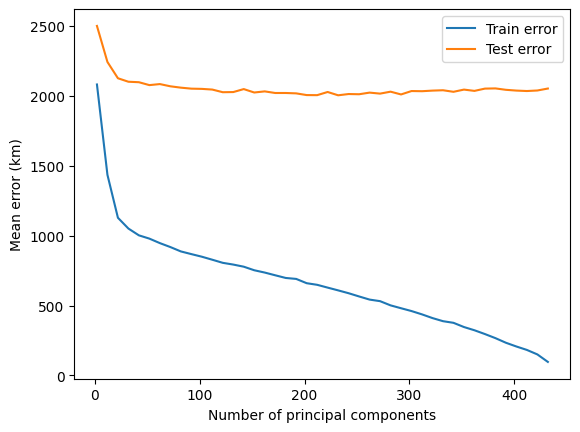

In [24]:
n_components_list = list(range(2, 441, 10))

mean_train_errors = []
mean_test_errors = []

for n_comp in n_components_list:
    train_errors = []
    test_errors = []

    for train_idx, test_idx in cv.split(X, Y, groups=groups):
        pcr = make_pipeline(PCA(n_components=n_comp), LinearRegression())
        
        pcr.fit(X[train_idx], Y[train_idx])

        Y_train_pred = pcr.predict(X[train_idx])
        Y_test_pred = pcr.predict(X[test_idx])

        train_dist = haversine(
            Y[train_idx][:, 0], Y[train_idx][:, 1],
            Y_train_pred[:, 0], Y_train_pred[:, 1]
        )

        test_dist = haversine(
            Y[test_idx][:, 0], Y[test_idx][:, 1],
            Y_test_pred[:, 0], Y_test_pred[:, 1]
        )

        train_errors.append(np.mean(train_dist))
        test_errors.append(np.mean(test_dist))
    mean_train_errors.append(np.mean(train_errors))
    mean_test_errors.append(np.mean(test_errors))

plt.plot(n_components_list, mean_train_errors, label='Train error')
plt.plot(n_components_list, mean_test_errors, label='Test error')

plt.xlabel('Number of principal components')
plt.ylabel('Mean error (km)')
plt.legend()
plt.show()

**(e)** Which model would you keep? What is the prediction error for this model? Compare it with its corresponding training error. Plot the predicted coordinates on a map as in **Exercise 4(a)**. What can you conclude?

<font color='green'>
The model we keep is the one corresponding to the number of principal components that minimizes the mean test error.

This model provides the best trade-off between bias and variance. Using fewer components would underfit the data, while using too many would lead to overfitting.

The prediction error of this model (in kilometers) is approximately equal to the minimum test error observed in the previous plot. This error is higher than the training error, which is expected since the model performs better on the data it was trained on.
The prediction error is approximately 2055 km, while the training error is around  605 km.

</font>

In [25]:
best_idx = np.argmin(mean_test_errors)
best_n = n_components_list[best_idx]

print("Best number of components:", best_n)
print("Test error (km):", mean_test_errors[best_idx])
print("Train error (km):", mean_train_errors[best_idx])

Best number of components: 232
Test error (km): 2002.8518836761261
Train error (km): 608.3543006452151


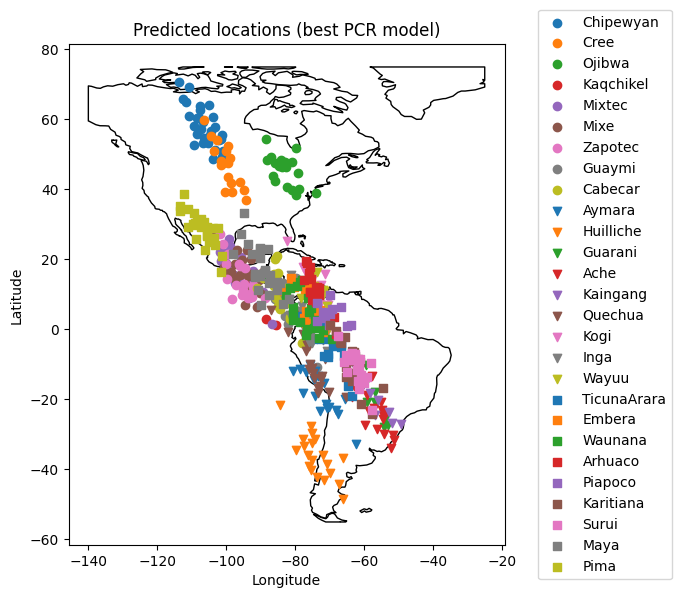

In [26]:
best_pcr = make_pipeline(PCA(n_components=best_n), LinearRegression())
best_pcr.fit(X, Y)

Y_pred = best_pcr.predict(X)
pred_lat = Y_pred[:, 0]
pred_long = Y_pred[:, 1]

fig, ax = plt.subplots(figsize=(8.0, 6.5))
world.clip([-140, -55, -25, 75]).plot(ax=ax, color='white', edgecolor='black')

for i, tribe in enumerate(tribes.unique()):
    members = tribes == tribe
    ax.scatter(pred_long[members], pred_lat[members],
               marker=marker_list[i//9],
               color=colors_list[i%9],
               label=tribe)

ax.legend(loc='center right', bbox_to_anchor=(1.4, 0.5))
ax.set_title('Predicted locations (best PCR model)')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.show()

## ▶️ Exercise 6: Conclusion (2 points)

Propose a conclusion to your study. You can write a paragraph about the quality of predictors versus the number of factors, possible improvements to the approach (for instance, showing what happens when using [partial least squares](https://scikit-learn.org/1.5/auto_examples/cross_decomposition/plot_pcr_vs_pls.html) instead of PCR), comment on the performance of the regression in predictions for each country separately, etc. Note that we expect a thorough presentation of the final predictive model as well as an interpretation of it, not simply a bunch of `python` code lines.

<font color='green'>

In this study, we investigated the use of genetic markers to predict the geographical origin of individuals using Principal Component Regression (PCR).

We showed that using all predictors directly is not feasible due to the high-dimensional nature of the data ($p > N$), which leads to singularity issues. PCA allowed us to reduce the dimensionality of the data and extract the most informative directions. We observed that a moderate number of principal components provides the best predictive performance: too few components lead to underfitting, while too many result in overfitting.

Using grouped cross-validation, we selected an optimal number of components that minimizes the prediction error in kilometers. This approach provided a more realistic estimate of the model's performance compared to evaluating it on the training data only.

The results show that genetic markers contain meaningful information about geographical origin, as individuals from the same population tend to be predicted in similar regions. However, prediction errors remain significant, indicating that the model is not perfectly accurate.

**Potential improvements:** One promising alternative would be to use Partial Least Squares (PLS) instead of PCR. Unlike PCR, which performs unsupervised dimensionality reduction and ignores the target variable, PLS performs supervised reduction that directly optimizes the relationship between genetic markers and geographical coordinates. This could potentially capture directions of variation that are more relevant for prediction and improve generalization. Additionally, a separate analysis of model performance by population/country could provide insights: some populations may have distinctive genetic signatures that are easier to predict, while others may be geographically and genetically more dispersed, leading to higher errors. Such analysis would help understand which populations benefit most from genetic prediction and which might require alternative approaches.

Overall, PCR combined with proper cross-validation provides a robust framework for predicting geographical origin from genetic data, while highlighting the importance of dimensionality reduction and careful model evaluation.

</font>